# RetinaNet 모델

In [1]:
### 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 0. 환경 준비
!nvidia-smi

Mon Mar 23 02:33:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   34C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### git 연결

In [3]:
# 1. 내 포크 clone
!git clone https://github.com/wina0901/pill_detection_project.git

# 2. 프로젝트 폴더로 이동
%cd pill_detection_project

# 3. requirements 설치
!pip install --upgrade pip
!pip install --index-url https://download.pytorch.org/whl/cu118 torch==2.7.1+cu118 torchvision==0.22.1+cu118 torchaudio==2.7.1+cu118
!pip install -r requirements.txt --no-deps


Cloning into 'pill_detection_project'...
remote: Enumerating objects: 323, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 323 (delta 20), reused 14 (delta 14), pack-reused 295 (from 1)
Receiving objects: 100% (323/323), 828.68 KiB | 36.03 MiB/s, done.
Resolving deltas: 100% (137/137), done.
/content/pill_detection_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 122.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 55.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 196.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 43.8 MB/s  0:00:07:00:0100:01


In [4]:
import sys
import os
sys.path.append("/content/pill_detection_project")

from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
    convert_yolo_results,
    convert_torchvision_outputs,
)


# 데이터 가져오기

In [5]:
import os
from src.preprocessing.dataset import get_loaders

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'  # Colab 기준

train_loader, val_loader, orig2model, num_classes, VAL_JSON_PATH = get_loaders(
    base_dir=BASE_DIR,
    batch_size=4,
    num_workers=2,
)

✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 1790장 / 6134개
✅ Val  : 139장 / 431개


# 모델 학습

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [8]:
############################################################
# RetinaNet
############################################################

import gc
import subprocess
import sys

try:
    import optuna
except ModuleNotFoundError as e:
    if e.name == "colorlog":
        subprocess.check_call([sys.executable, "-m", "pip", "install", "colorlog"])
        import optuna
    else:
        raise
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead


def build_retinanet_model(num_classes):
    model = retinanet_resnet50_fpn(weights="DEFAULT")
    cls_head = model.head.classification_head

    # torchvision ??? ?? conv[0]? Conv2dNormActivation? ? ????
    # ?? ? Conv2d? ?? ?? ?? ???.
    first_conv = next(
        module for module in cls_head.conv.modules() if isinstance(module, nn.Conv2d)
    )
    in_channels = first_conv.in_channels
    num_anchors = cls_head.num_anchors

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )
    return model


def train_retinanet(
    lr,
    num_epochs=30,
    patience=10,
    min_delta=1e-3,
    save_best_path=None,
    history_path=None,
    run_name="RetinaNet",
):
    model = build_retinanet_model(num_classes)
    model.to(DEVICE)

    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=1e-4,
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    best_val_loss = float("inf")
    early_stop_counter = 0
    history = init_history()
    model2orig = {v: k for k, v in orig2model.items()}

    for epoch in range(1, num_epochs + 1):
        ##########################
        # 1) Train
        ##########################
        model.train()
        train_loss_sum = 0.0

        for images, targets in train_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            train_loss_sum += losses.item()

        epoch_train_loss = train_loss_sum / max(1, len(train_loader))

        ##########################
        # 2) Validation
        ##########################
        model.train()
        val_loss_sum = 0.0

        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss_sum += losses.item()

        epoch_val_loss = val_loss_sum / max(1, len(val_loader))

        all_outputs = []
        all_image_ids = []

        model.eval()
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(DEVICE) for img in images]
                outputs = model(images)

                batch_image_ids = [t["image_id"].item() for t in targets]
                all_outputs.extend(outputs)
                all_image_ids.extend(batch_image_ids)

        temp_eval_name = run_name.lower().replace(" ", "_")
        val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)
        metrics = evaluate_all(
            gt_json_path=VAL_JSON_PATH,
            predictions=val_predictions,
            conf_threshold=0.25,
            pr_iou_threshold=0.5,
            temp_json_path=f"retinanet_temp_eval_{temp_eval_name}_epoch_{epoch}.json",
            model2orig=model2orig,
        )

        update_history(
            history,
            epoch=epoch,
            train_loss=epoch_train_loss,
            val_loss=epoch_val_loss,
            metrics=metrics,
        )

        print(
            f"[{run_name} Epoch {epoch}/{num_epochs}] "
            f"lr: {lr:.6g} | "
            f"train_loss: {epoch_train_loss:.4f} | "
            f"val_loss: {epoch_val_loss:.4f} | "
            f"mAP@75:95: {metrics['mAP@75:95']:.4f} | "
            f"mAP@50: {metrics['mAP@50']:.4f} | "
            f"precision: {metrics['precision']:.4f} | "
            f"recall: {metrics['recall']:.4f}"
        )

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            early_stop_counter = 0
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)
            print(f"  -> best val_loss ??: {best_val_loss:.4f}")
        else:
            early_stop_counter += 1
            print(f"  -> ?? ?? ({early_stop_counter}/{patience})")

        if early_stop_counter >= patience:
            print(f"Early Stopping ??: patience={patience}")
            break

        scheduler.step()

    if history_path is not None:
        save_history(history, history_path)

    return model, history, best_val_loss


In [9]:
############################################################
# RetinaNet lr Optuna
############################################################

optuna_epochs = 5
optuna_patience = 3
optuna_trials = 10

final_num_epochs = 30
final_patience = 10
min_delta = 1e-3


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    model, history, best_val_loss = train_retinanet(
        lr=lr,
        num_epochs=optuna_epochs,
        patience=optuna_patience,
        min_delta=min_delta,
        save_best_path=None,
        history_path=None,
        run_name=f"RetinaNet Trial {trial.number}",
    )

    del model, history
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_loss


study = optuna.create_study(direction="minimize", study_name="retinanet_lr_only")
study.optimize(objective, n_trials=optuna_trials)

best_lr = study.best_trial.params["lr"]
print(f"Best trial: {study.best_trial.number}")
print(f"Best lr: {best_lr:.6g}")
print(f"Best val_loss: {study.best_value:.4f}")

model, history, best_val_loss = train_retinanet(
    lr=best_lr,
    num_epochs=final_num_epochs,
    patience=final_patience,
    min_delta=min_delta,
    save_best_path="retinanet_oral_drug.pth",
    history_path="history_retinanet.json",
    run_name="RetinaNet Final",
)

print(f"RetinaNet| tuned lr={best_lr:.6g} | best_val_loss={best_val_loss:.4f}")


[I 2026-03-23 02:38:29,491] A new study created in memory with name: retinanet_lr_only


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 240MB/s] 


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.10s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.59s).
Accumulating evaluation results...
DONE (t=0.68s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.106
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.512
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.788
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

[I 2026-03-23 03:02:44,031] Trial 0 finished with value: 0.2772428478513445 and parameters: {'lr': 0.000285359693472478}. Best is trial 0 with value: 0.2772428478513445.


...

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[RetinaNet Trial 8 Epoch 1/5] lr: 0.00077837 | train_loss: 2.2958 | val_loss: 1.7586 | mAP@75:95: 0.0000 | mAP@50: 0.0000 | precision: 0.0000 | recall: 0.0000
  -> best val_loss ??: 1.7586
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[RetinaNet Trial 8 Epoch 2/5] lr: 0.00077837 | train_loss: 1.7171 | val_loss: 1.7104 | mAP@75:95: 0.0000 | mAP@50: 0.0000 | precision: 0.0000 | recall: 0.0000
  -> best val_loss ??: 1.7104
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[RetinaNet Trial 8 Epoch 3/5] lr: 0.00077837 | train_loss: 1.7059 | val_loss: 1.7077 | mAP@75:95: 0.0000 | mAP@50: 0.0000 | precision: 0.0000 | recall: 0.0000
  -> best val_loss ??: 1.7077
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[RetinaNet Trial 8 Epoch 4/5] lr: 0.00077837 | train_loss: 1.7036 | val_loss: 1.7074 | mAP@75:95: 0.0

[I 2026-03-23 05:02:37,169] Trial 8 finished with value: 1.7077464921133858 and parameters: {'lr': 0.0007783698557048096}. Best is trial 6 with value: 0.2043325554047312.


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.09s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.58s).
Accumulating evaluation results...
DONE (t=0.72s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.249
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.253
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.253
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.253
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.775
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.871
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

[I 2026-03-23 05:17:45,128] Trial 9 finished with value: 0.2166463900889669 and parameters: {'lr': 3.9160492404336704e-05}. Best is trial 6 with value: 0.2043325554047312.


Best trial: 6
Best lr: 0.000137159
Best val_loss: 0.2043
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.10s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.80s).
Accumulating evaluation results...
DONE (t=0.76s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.191
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.199
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.199
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.500
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.192
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.774
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.934
 Averag

# 모델 평가

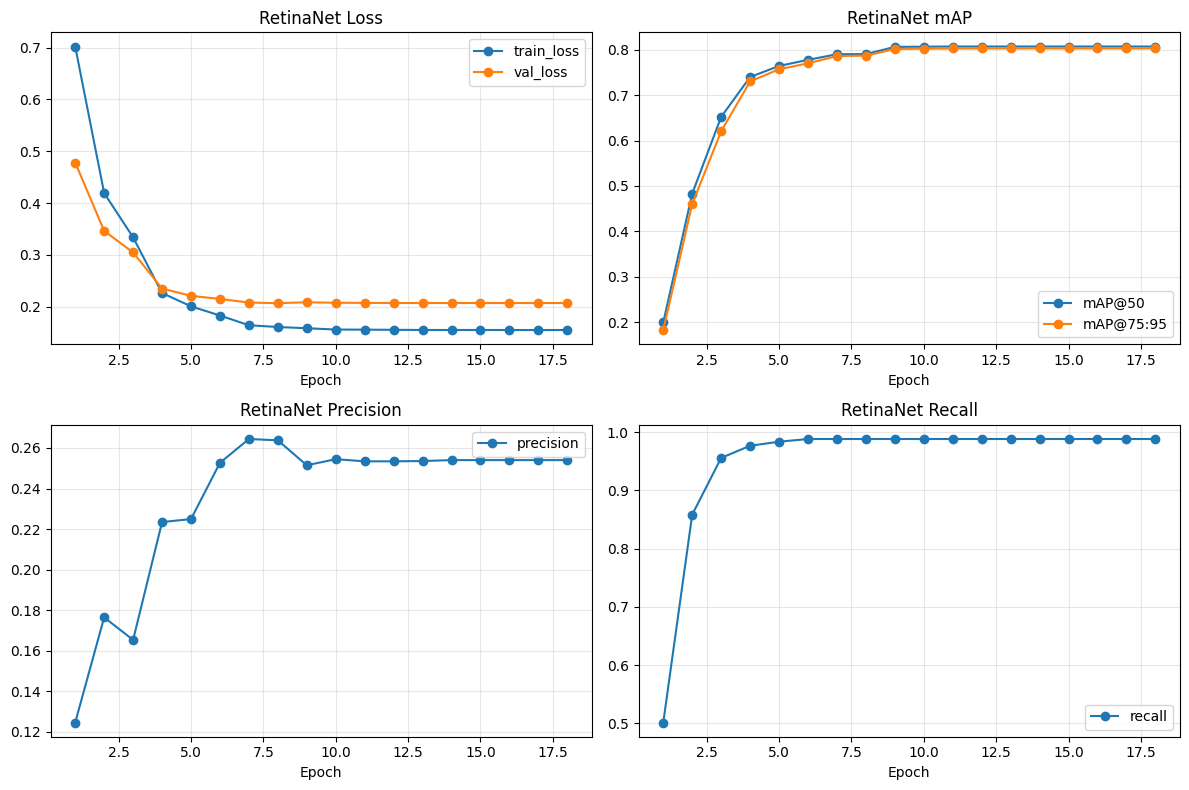

In [10]:
history = load_history("history_retinanet.json")
plot_training_history(history, title_prefix="RetinaNet")

# 시각화

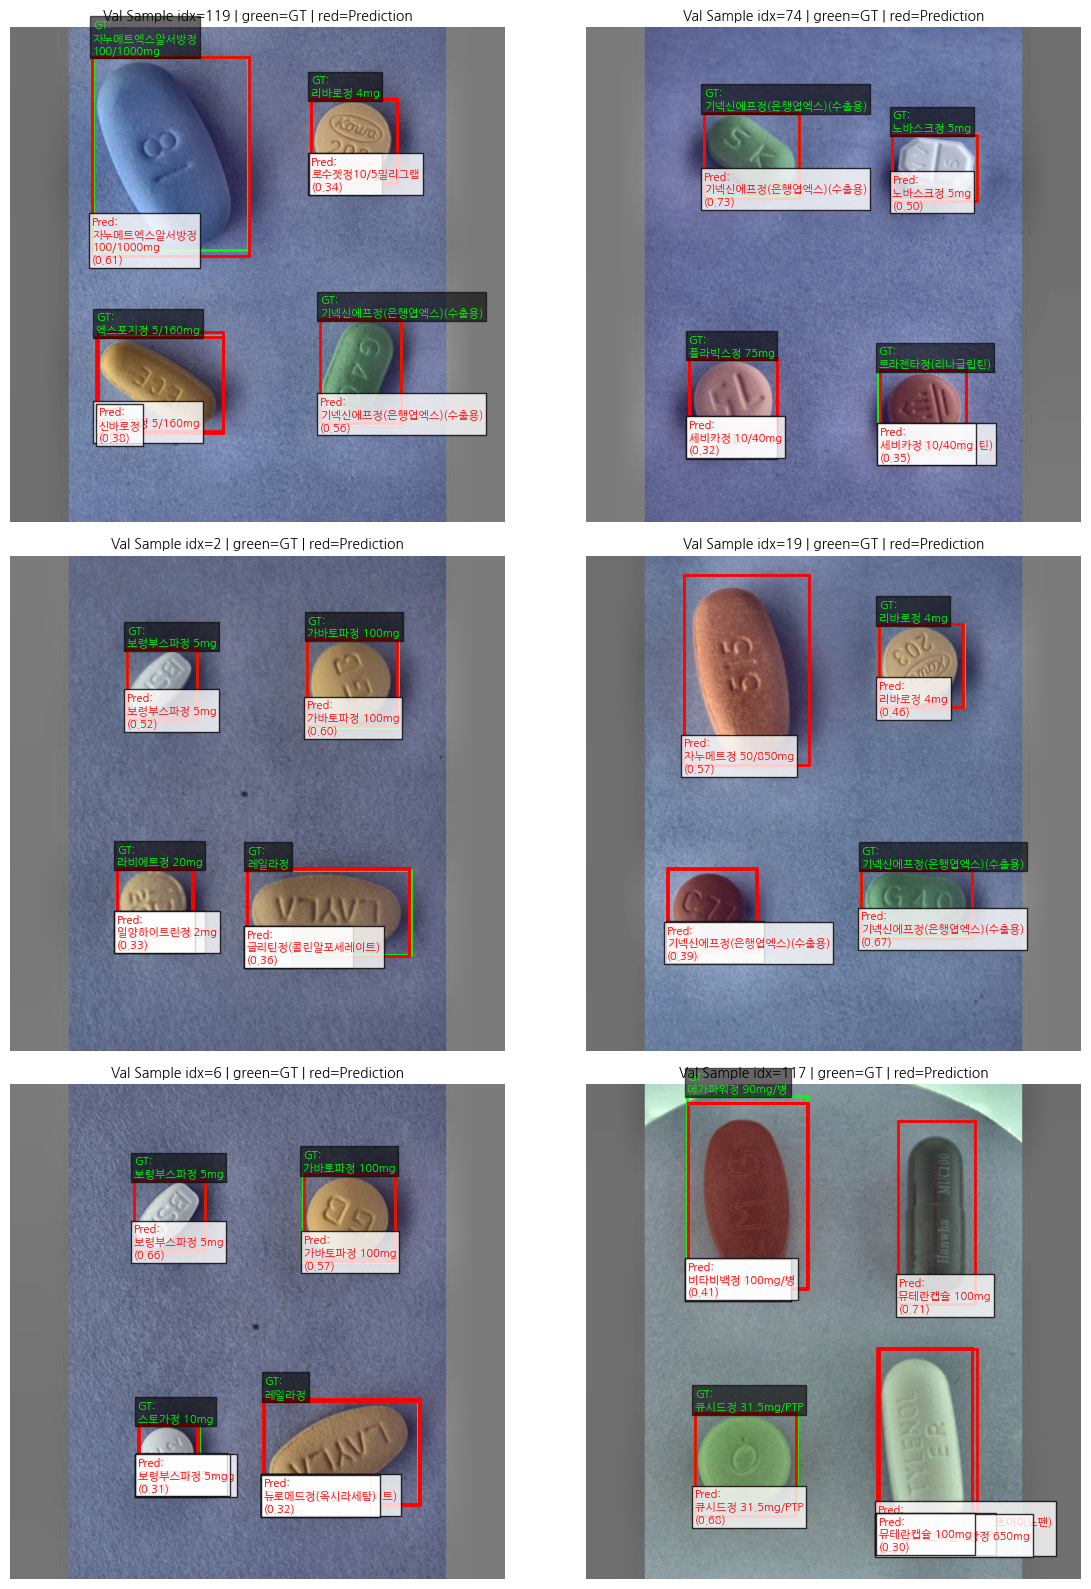

In [11]:
import json
import os
import random
import shutil
import subprocess
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import torch

def configure_colab_font():
    if shutil.which("apt-get"):
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-nanum", "fonts-nanum-extra"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    if shutil.which("fc-cache"):
        subprocess.run(
            ["fc-cache", "-fv"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    fm._load_fontmanager(try_read_cache=False)
    font_candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    ]

    selected_path = next((path for path in font_candidates if os.path.exists(path)), None)

    if selected_path is not None:
        font_prop = FontProperties(fname=selected_path)
        selected_font = font_prop.get_name()
    else:
        available_fonts = {font.name for font in fm.fontManager.ttflist}
        preferred_fonts = [
            "NanumGothic",
            "NanumBarunGothic",
            "Noto Sans CJK KR",
            "Noto Sans KR",
            "DejaVu Sans",
        ]
        selected_font = next((name for name in preferred_fonts if name in available_fonts), "DejaVu Sans")
        font_prop = FontProperties(family=selected_font)

    plt.rcParams["font.family"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return font_prop, selected_font

font_prop, font_name = configure_colab_font()

with open(VAL_JSON_PATH, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

cat_id_to_name = {c["id"]: c["name"] for c in val_coco["categories"]}
model2orig = {v: k for k, v in orig2model.items()}

NUM_SAMPLES = 6
SCORE_THRESH = 0.3
N_COLS = 2
N_ROWS = 3

def wrap_label(prefix, name, width=18, score=None):
    wrapped_name = "\n".join(textwrap.wrap(str(name), width=width))
    if score is None:
        return f"{prefix}:\n{wrapped_name}"
    return f"{prefix}:\n{wrapped_name}\n({score:.2f})"

sample_indices = random.sample(
    range(len(val_loader.dataset)),
    k=min(NUM_SAMPLES, len(val_loader.dataset))
)

model.eval()

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 16))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        image, target = val_loader.dataset[idx]
        output = model([image.to(DEVICE)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)
        ax.axis("off")

        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()

        for box, label in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = box
            orig_cat = model2orig.get(int(label), int(label))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, max(y1 - 5, 5),
                wrap_label("GT", pill_name, width=18),
                color="lime",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.6, pad=2),
                fontproperties=font_prop
            )

        pred_boxes = output["boxes"].detach().cpu().numpy()
        pred_scores = output["scores"].detach().cpu().numpy()
        pred_labels = output["labels"].detach().cpu().numpy()

        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            if score < SCORE_THRESH:
                continue

            x1, y1, x2, y2 = box
            orig_cat = model2orig.get(int(label), int(label))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, min(y2 + 12, img_np.shape[0] - 5),
                wrap_label("Pred", pill_name, width=18, score=score),
                color="red",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.8, pad=2),
                fontproperties=font_prop
            )

        ax.set_title(
            f"Val Sample idx={idx} | green=GT | red=Prediction",
            fontproperties=font_prop,
        )

for ax in axes[len(sample_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 가중치 및 학습 결과 구글 드라이브에 저장

In [12]:
import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/pill_detection_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/pill_detection_project/retinanet_oral_drug.pth", SAVE_DIR)
shutil.copy("/content/pill_detection_project/history_retinanet.json", SAVE_DIR)

print(os.listdir(SAVE_DIR))

['retinanet_oral_drug.pth', 'history_retinanet.json']


In [13]:
import requests

webhook_url = "https://discord.com/api/webhooks/1484101399792058379/RmmWK-rC4qJhpDUJtgO9OwEwMzLuUJ-_NNp62V33g1_Cny5sg13MhOE4RV3sMCy8D4M5"
data = {"content": "RetinaNet 학습이 완료됐습니다."}
requests.post(webhook_url, json=data)


<Response [204]>